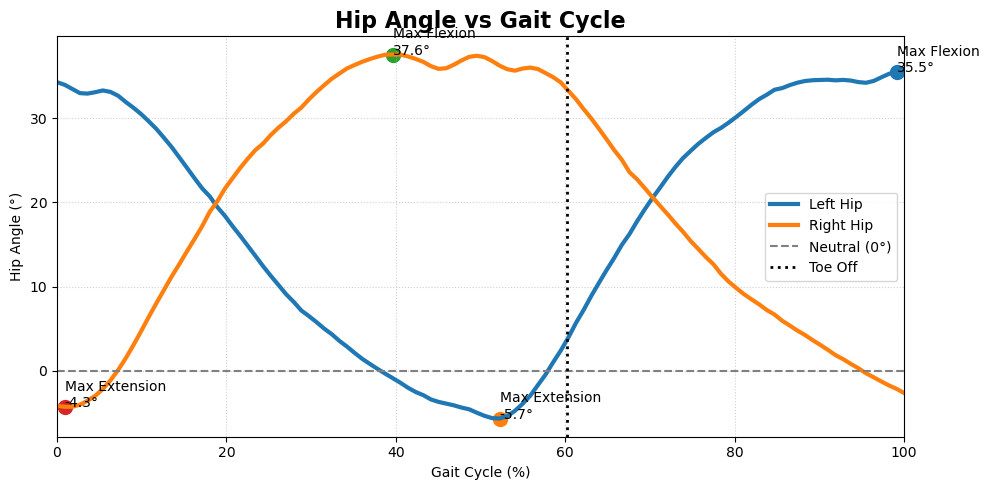

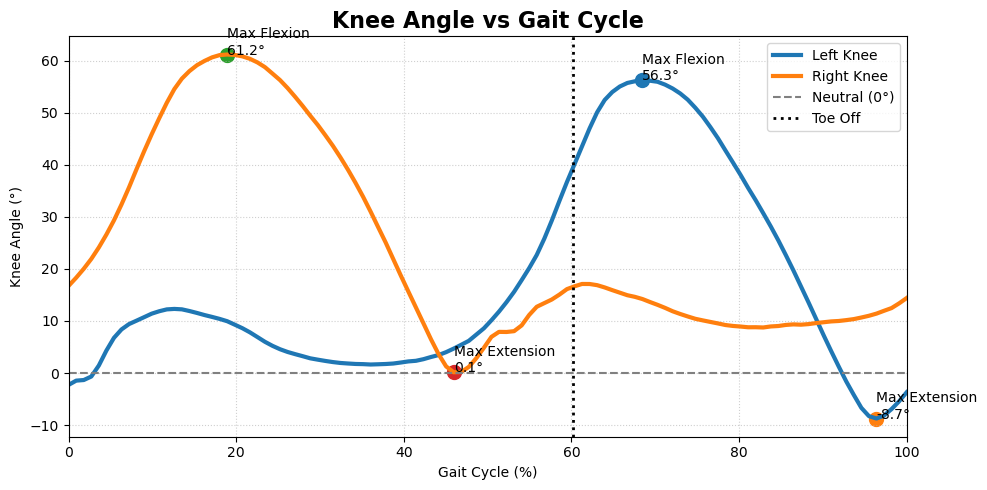

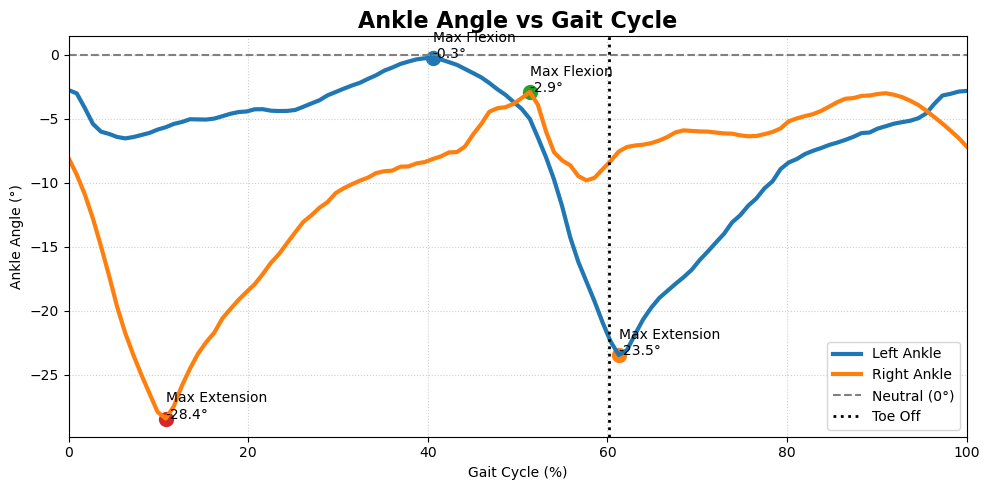


Hip
------------------------------
Left ROM : 41.23°
Right ROM: 41.89°

Knee
------------------------------
Left ROM : 64.99°
Right ROM: 61.06°

Ankle
------------------------------
Left ROM : 23.20°
Right ROM: 25.50°

Hip
------------------------------
Left Max : 35.53°
Left Min : -5.70°
Right Max: 37.59°
Right Min: -4.31°

Knee
------------------------------
Left Max : 56.25°
Left Min : -8.74°
Right Max: 61.20°
Right Min: 0.14°

Ankle
------------------------------
Left Max : -0.26°
Left Min : -23.46°
Right Max: -2.93°
Right Min: -28.43°


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Metadata

metadata = {
    "frame_number": 114,
    "first_frame": 336,
    "point_frequency": 100,
    "analog_frequency": 100,
    "bw": 78
}

events = {
    "LHS_start": 3.35,
    "LHS_end": 4.48,
    "RHS": 3.91,
    "LTO": 4.03,
}

# Read Excel

df = pd.read_excel(
    "Walk_002.xlsx",
    header=None
)

# Extract data

time = pd.to_numeric(
    df.iloc[125:237, 0],
    errors="coerce"
).reset_index(drop=True)

LHIP_angle = pd.to_numeric(df.iloc[8:120, 49], errors="coerce").reset_index(drop=True)
LKNEE_angle = pd.to_numeric(df.iloc[8:120, 52], errors="coerce").reset_index(drop=True)
LANKLE_angle = pd.to_numeric(df.iloc[8:120, 55], errors="coerce").reset_index(drop=True)

RHIP_angle = pd.to_numeric(df.iloc[8:120, 58], errors="coerce").reset_index(drop=True)
RKNEE_angle = pd.to_numeric(df.iloc[8:120, 61], errors="coerce").reset_index(drop=True)
RANKLE_angle = pd.to_numeric(df.iloc[8:120, 64], errors="coerce").reset_index(drop=True)

# Time Normalisation

time_norm = (
    (time - time.iloc[0])
    /
    (time.iloc[-1] - time.iloc[0])
) * 100

# Toe-Off Position

toe_off = (
    (events["LTO"] - events["LHS_start"])
    /
    (events["LHS_end"] - events["LHS_start"])
) * 100

# Plot Function

def plot_joint(time_norm, left, right, joint_name):

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(time_norm, left, linewidth=3, label=f"Left {joint_name}")
    ax.plot(time_norm, right, linewidth=3, label=f"Right {joint_name}")

    # Neutral line
    ax.axhline(
        0,
        linestyle="--",
        color="grey",
        linewidth=1.5,
        label="Neutral (0°)"
    )

    # Toe-off
    ax.axvline(
        toe_off,
        linestyle=":",
        color="black",
        linewidth=2,
        label="Toe Off"
    )

    # Left max/min
    left_max_idx = left.idxmax()
    left_min_idx = left.idxmin()

    ax.scatter(
        time_norm.iloc[left_max_idx],
        left.iloc[left_max_idx],
        s=100
    )

    ax.scatter(
        time_norm.iloc[left_min_idx],
        left.iloc[left_min_idx],
        s=100
    )

    # Right max/min
    right_max_idx = right.idxmax()
    right_min_idx = right.idxmin()

    ax.scatter(
        time_norm.iloc[right_max_idx],
        right.iloc[right_max_idx],
        s=100
    )

    ax.scatter(
        time_norm.iloc[right_min_idx],
        right.iloc[right_min_idx],
        s=100
    )

    ax.annotate(
        f"Max Flexion\n{left.max():.1f}°",
        (
            time_norm.iloc[left_max_idx],
            left.iloc[left_max_idx]
        )
    )

    ax.annotate(
        f"Max Flexion\n{right.max():.1f}°",
        (
            time_norm.iloc[right_max_idx],
            right.iloc[right_max_idx]
        )
    )

    ax.annotate(
        f"Max Extension\n{left.min():.1f}°",
        (
            time_norm.iloc[left_min_idx],
            left.iloc[left_min_idx]
        )
    )

    ax.annotate(
        f"Max Extension\n{right.min():.1f}°",
        (
            time_norm.iloc[right_min_idx],
            right.iloc[right_min_idx]
        )
    )

    ax.set_title(
        f"{joint_name} Angle vs Gait Cycle",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_xlabel("Gait Cycle (%)")
    ax.set_ylabel(f"{joint_name} Angle (°)")

    ax.set_xlim(0, 100)

    ax.grid(
        True,
        linestyle=":",
        alpha=0.6
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

# ROM Function

def print_rom(left, right, joint_name):

    left_rom = left.max() - left.min()
    right_rom = right.max() - right.min()

    print(f"\n{joint_name}")
    print("-" * 30)
    print(f"Left ROM : {left_rom:.2f}°")
    print(f"Right ROM: {right_rom:.2f}°")

# MAX-MIN Function

def print_MAX_MIN(left, right, joint_name):

    left_max = left.max()
    left_min = left.min()

    right_max = right.max()
    right_min = right.min()

    print(f"\n{joint_name}")
    print("-" * 30)
    print(f"Left Max : {left_max:.2f}°")
    print(f"Left Min : {left_min:.2f}°")
    print(f"Right Max: {right_max:.2f}°")
    print(f"Right Min: {right_min:.2f}°")

# Generate Graphs

plot_joint(time_norm, LHIP_angle, RHIP_angle, "Hip")
plot_joint(time_norm, LKNEE_angle, RKNEE_angle, "Knee")
plot_joint(time_norm, LANKLE_angle, RANKLE_angle, "Ankle")

# Print Metrics

print_rom(LHIP_angle, RHIP_angle, "Hip")
print_rom(LKNEE_angle, RKNEE_angle, "Knee")
print_rom(LANKLE_angle, RANKLE_angle, "Ankle")

print_MAX_MIN(LHIP_angle, RHIP_angle, "Hip")
print_MAX_MIN(LKNEE_angle, RKNEE_angle, "Knee")
print_MAX_MIN(LANKLE_angle, RANKLE_angle, "Ankle")

